In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import glob 
import soundfile as sf 
rng = np.random.default_rng()
import librosa
import IPython.display as ipd
import os

In [2]:
# Defining the function to select top k indices from the array and set them to 1 and the rest to 0
# Equivalent of selecting top k neurons from a system of N neurons

def k_cap(input, cap_size):
    output = np.zeros_like(input)
    if len(input.shape) == 1:
        idx = np.argsort(input)[-cap_size:]
        output[idx] = 1
    else:
        idx = np.argsort(input, axis=-1)[:, -cap_size:]
        np.put_along_axis(output, idx, 1, axis=-1)
    return output

In [3]:
# Define the path to the main folder containing TIMIT data set Training Data

TIMIT_folder_path = r"C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN"
TIMIT_folder_contents = os.listdir(TIMIT_folder_path)
print(TIMIT_folder_contents)

vowel_segments = []
data_labels = []

# Inside the main folder are regional dialect folders 
for regional_dialects in TIMIT_folder_contents:
    regional_dialects_path = os.path.join(TIMIT_folder_path,regional_dialects)
    vowel_array = np.array(['greasy','water','dark'])
    print(regional_dialects_path)

    # Navigation through Volunteer wise folders in regional dialects folder 
    volunteer_id_contents = os.listdir(regional_dialects_path)

    for item in volunteer_id_contents:
        
        # Now finally we are in the folder where all wrd and wav files are present
        # Wrd files contains information of starting and ending sample of each word
        # Wav files contain the spoken sentence in wav format 
                
        folder_path = os.path.join(regional_dialects_path, item)
        
        # Use glob to find all .wav and .wrd files in the folder
        wav_files = glob.glob(folder_path + '\\*.wav')
        wrd_files = glob.glob(folder_path + '\\*.wrd')

        # Sort files to ensure they are processed in the same order
        wav_files.sort()
        wrd_files.sort()   

        # Iterate over each pair of corresponding .wav and .wrd file
        for wav_file, wrd_file in zip(wav_files, wrd_files):
            
            # Load audio file
            y, Fs = sf.read(wav_file)

            # Load .wrd file
            with open(wrd_file, 'r') as f:
                
                # Read the contents of the .wrd file as strings
                wrd_data = [line.strip() for line in f]

                # Convert wrd_data to a NumPy array
                wrd_data_array = np.array([line.split() for line in wrd_data])

                # Check which elements of word_array are present in wrd_data_array
                mask = np.isin(wrd_data_array[:, -1], vowel_array)

                # Get the indices where the condition is True
                indices = np.where(mask)[0]

                # Once we have the indexes of the starting and ending samples of the word from wrd files 
                # We extract the wav file samples between those indexes to get the audio samples of that particular word
                
                # Extract the first two columns corresponding to the indices where the condition is True
                selected_data = wrd_data_array[indices, :3]
       
                # Iterate over each row in selected_data
                for row in selected_data:
                # Convert start and end points to integers
                    start_point = int(row[0])
                    end_point = int(row[1])

                    # Extract the segment from the signal y
                    segment = y[start_point:end_point]
                    #print(segment.shape)

                    if(5000<len(segment)<6500):
                        midpoint = len(segment) // 2

                        # Calculate the starting point for the segment
                        start_point = midpoint - (4000 // 2)

                        # Extract the segment from the signal
                        truncated_segment = segment[start_point:start_point + 4000]  
                        vowel_segments.append(truncated_segment)
                        data_labels.append(row[2])
                 
print('All folders read')

['DR1', 'DR2', 'DR3', 'DR4', 'DR5', 'DR6', 'DR7', 'DR8']
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR1
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR2
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR3
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR4
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR5
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR6
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR7
C:\Users\singh\Documents\UNSW\Thesis\Codes\TIMIT\data\TRAIN\DR8
All folders read


In [4]:
vowel_array = np.array(['greasy','water','dark'])
vowel_segments_array=np.array(vowel_segments)
data_labels=np.array(data_labels)

idx_dict = {}
classes=0
for vowel in vowel_array:
    idx_dict[vowel] = np.where(data_labels == vowel)[0]
    
    #Checking which word has been found how many times as per the size restrictions
    
    print(vowel)
    print(len(idx_dict[vowel]))
    classes=classes+1

greasy
276
water
102
dark
272


In [5]:
vowel_samples_taken=100
sorted_3d = []

#Iterate over each vowel in vowel_array
for vowel in vowel_array:
    # Get the indexes of the current vowel
    indexes = idx_dict[vowel]
    print(vowel)
    
    # Take the first 20 indexes if there are at least 10
    indexes_20 = indexes[:vowel_samples_taken]
     
    # Iterate over the first 10 indexes and extract the corresponding spectrograms
    for index in indexes_20:
        sorted_segments = vowel_segments_array[index]
        sorted_3d.append(sorted_segments)

sorted_3d=np.array(sorted_3d)
print(sorted_3d.shape)

greasy
water
dark
(300, 4000)


In [6]:
import IPython.display as ipd

#To run and check random words and how they sound from training data

ipd.Audio(sorted_3d[10,:], rate=Fs)

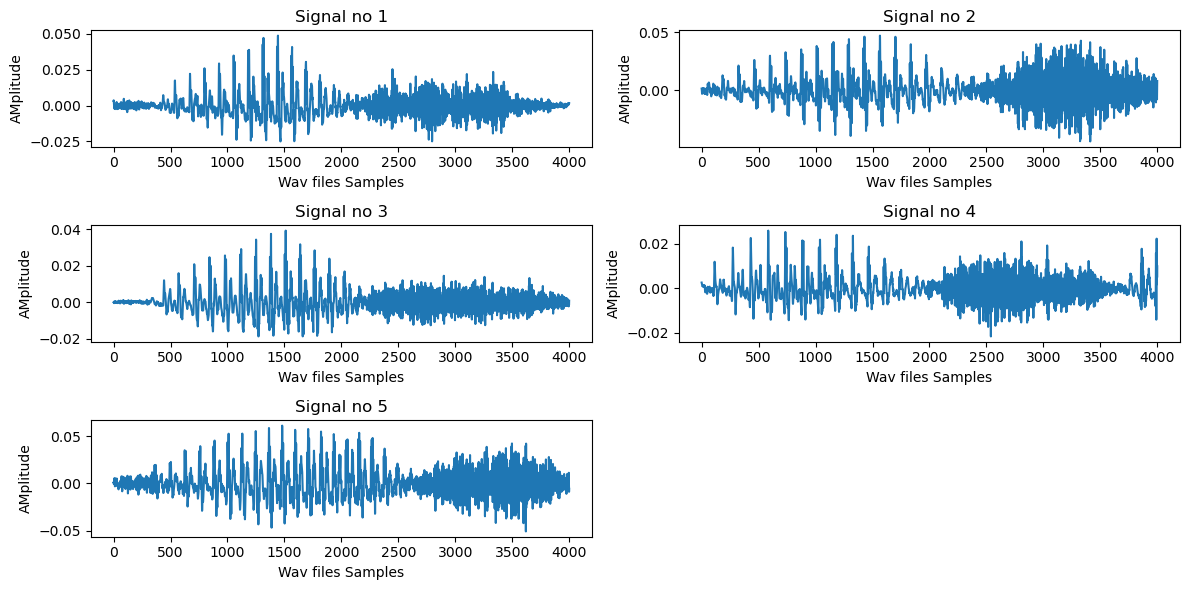

In [7]:
# To check how amplitude/energy siganls look like for each class and check the consistency of distribution
# Just a debugging code

plt.figure(figsize=(12, 6))  # Adjust the size as needed

for i in range(5): 
    plt.subplot(3,2,i+1)
    #plt.plot(vowel_segments_array[i,:])
    plt.plot(sorted_3d[i+10,:])
    plt.title(f'Signal no {i+1}')
    plt.xlabel("Wav files Samples")
    plt.ylabel("AMplitude")
    
# Adjust layout
plt.tight_layout()


In [8]:
window_size = 330  # Size of the window for collecting voice samples
overlap = 0.2  # Overlap between consecutive windows (50% overlap)

spectrograms_3d=[]

for i in range(classes*vowel_samples_taken):
    #Extarcting the tuncated signal from the earlier sorted array for calculating the spectrogram
    signal=sorted_3d[i,:]
                    
    # Compute the Short-Time Fourier Transform (STFT)
    Sxx = np.abs(librosa.stft(signal, n_fft=window_size, hop_length=int(window_size * (1 - overlap))))

    # Convert magnitude spectrogram to decibels (dB)
    Sxx_db = librosa.amplitude_to_db(Sxx, ref=np.max)

    Sxx_flat=Sxx_db.reshape(-1)
    
    #Taking the top cap_size features as they have the most effect on the data
    # Making the indices of top k_cap features as 1 and rest as 0 as per the requirement of the model 
    
    cap_size = 200
    spectrograms_3d.append(k_cap(Sxx_flat,cap_size))

#Stacking all spectrograms in a 3D matrix of size classes x vowel_samples x spectrogram

spectrograms_3d_array = (np.array(spectrograms_3d)).reshape(classes,vowel_samples_taken,-1)
spectrograms_3d = (np.array(spectrograms_3d))

# Dividing all spectrograms data in traing and testing data for further calculation 
# Keeping only 5 samples for training and sending rest 95 for testing 

train_examples = spectrograms_3d_array[:,:5,:]
test_examples = spectrograms_3d_array[:,5:,:]

print(Sxx.shape)
print(spectrograms_3d.shape)
print(spectrograms_3d_array.shape)
print(train_examples.shape) 
print(test_examples.shape)

(166, 16)
(300, 2656)
(3, 100, 2656)
(3, 5, 2656)
(3, 95, 2656)


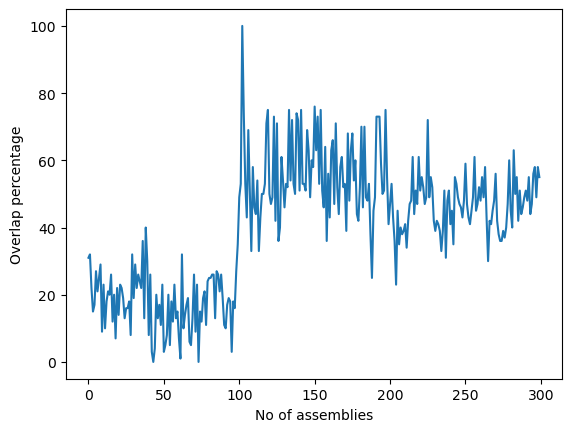

In [9]:
temp=[]
cap_size=100

sorted_indices = spectrograms_3d[102,:].argsort()[-cap_size:][::-1]

for i in range(classes*vowel_samples_taken):
    op_sorted = spectrograms_3d[i,:].argsort()[-cap_size:][::-1]  
    overlap = np.intersect1d(sorted_indices, op_sorted)
    overlap_percentage = len(overlap) / len(sorted_indices) * 100
    #print("Overlap percentage with class ",i, ":", overlap_percentage)
    temp.append(overlap_percentage)
plt.plot(temp)
plt.xlabel("No of assemblies")
plt.ylabel("Overlap percentage")
plt.show()



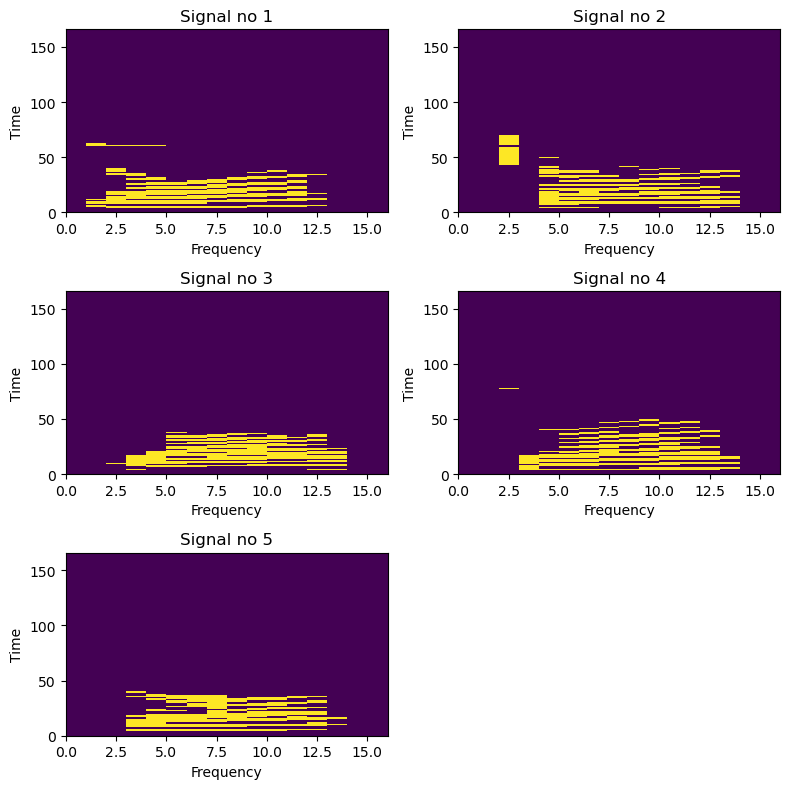

In [10]:
# Debugging code block
# To check consistency of training and testing spectrograms for the model

plt.figure(figsize=(8, 8))  # Adjust the size as needed

for i in range(5): 
    spectro = test_examples[2,i, :].reshape(166,16)   
    #spectro = train_examples[2,i, :].reshape(166,16)   
    plt.subplot(3,2,i+1)
    plt.pcolormesh(spectro)
    plt.title(f'Signal no {i+1}')
    plt.xlabel("Frequency")
    plt.ylabel("Time")
    
# Adjust layout
plt.tight_layout()


In [11]:
n_in = 2656
n_neurons = 10000
cap_size = 200
sparsity = 0.1
n_rounds = 5
beta = 1e0
mask = np.zeros((n_neurons, n_neurons), dtype=bool)
W = np.zeros((n_neurons, n_neurons))
mask_a = np.zeros((n_in, n_neurons), dtype=bool)
A = np.zeros((n_in, n_neurons))
mask = (rng.random((n_neurons, n_neurons)) < sparsity) & np.logical_not(np.eye(n_neurons, dtype=bool))
W = np.ones((n_neurons, n_neurons)) * mask
W /= W.sum(axis=0)
mask_a = rng.random((n_in, n_neurons)) < sparsity
A = np.ones((n_in, n_neurons)) * mask_a
A /= A.sum(axis=0)

In [12]:
W = np.ones_like(W) * mask
A = np.ones_like(A) * mask_a
W /= W.sum(axis=0, keepdims=True)
A /= A.sum(axis=0, keepdims=True)
bias = np.zeros(n_neurons)
b = -1
activations = np.zeros((classes, n_rounds, n_neurons))
for i in range(classes):
    act_h = np.zeros(n_neurons)
    for j in range(n_rounds):
        input = train_examples[i, j]
        act_h_new = k_cap(act_h @ W + input @ A + bias, cap_size)
        activations[i, j] = act_h_new.copy()
        A[(input > 0)[:, np.newaxis] & (act_h_new > 0)[np.newaxis, :]] *= 1 + beta
        W[(act_h > 0)[:, np.newaxis] & (act_h_new > 0)[np.newaxis, :]] *= 1 + beta
        act_h = act_h_new
    bias[act_h > 0] += b
    A /= A.sum(axis=0, keepdims=True)
    W /= W.sum(axis=0, keepdims=True)
    

In [13]:
outputs = np.zeros((classes, n_rounds+1, test_examples.shape[1], n_neurons))
for i in np.arange(classes):
    for j in range(n_rounds):
        outputs[i, j+1] = k_cap(outputs[i, j] @ W + test_examples[i] @ A, cap_size)
       

In [14]:
# Final activations of class 1 after learning 
sorted_indices = activations[1,n_rounds-1,:].argsort()[-cap_size:][::-1]

# Looping over all assemblies formed class wise to check which overlaps max with the above assembly

for j in range(classes):
    for i in range(n_rounds):
        op_sorted = activations[j,i,:].argsort()[-cap_size:][::-1]  
        overlap = np.intersect1d(sorted_indices, op_sorted)
        overlap_percentage = len(overlap) / len(sorted_indices) * 100
        print("Overlap percentage with class ",j, ":", overlap_percentage)
        
# As we can see the overlap of Class 1 assembly with assembly of any other class is bare minimum <10 -- expected result 
# Overalp with initial assmeblies of Class 1 is large and grows to 100% in just few samples means the system has learned 

Overlap percentage with class  0 : 2.0
Overlap percentage with class  0 : 1.5
Overlap percentage with class  0 : 1.0
Overlap percentage with class  0 : 0.0
Overlap percentage with class  0 : 0.0
Overlap percentage with class  1 : 97.0
Overlap percentage with class  1 : 100.0
Overlap percentage with class  1 : 100.0
Overlap percentage with class  1 : 100.0
Overlap percentage with class  1 : 100.0
Overlap percentage with class  2 : 0.0
Overlap percentage with class  2 : 0.0
Overlap percentage with class  2 : 0.0
Overlap percentage with class  2 : 0.0
Overlap percentage with class  2 : 0.0


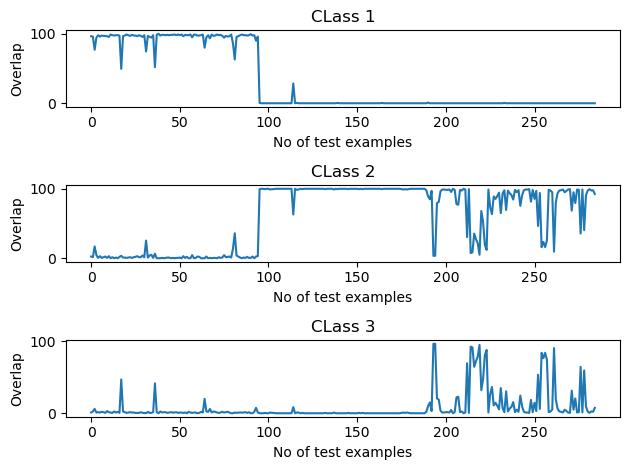

In [22]:
#Code block to check the prediction results 

for k in range(classes):
    
    # Final activations of each class -- learned assmembly for corresponding class
    sorted_indices = activations[k,n_rounds-1,:].argsort()[-cap_size:][::-1]
    p=[]
    
    for j in range(classes):
        for i in range(test_examples.shape[1]):
            
            # Assembly created due to each test example 
            op_sorted=outputs[j,n_rounds-1,i,:].argsort()[-cap_size:][::-1]
            
            #Checking overlap for each class
            overlap = np.intersect1d(sorted_indices, op_sorted)
            overlap_percentage = len(overlap) / len(sorted_indices) * 100
            p.append(overlap_percentage)
    plt.subplot(classes,1,k+1)
    plt.plot(p)
    plt.xlabel("No of test examples")
    plt.ylabel("Overlap")  
    plt.title(f'CLass {k+1}')

    
# Adjust layout
plt.tight_layout() 
  
## AS we can see from the below graphs the learned assembly corresponding to the first class overlaps
# significantly with first 95 test examples as they belong to class 1 and bare minimun overlap with test examples of any other class
# For class 2 and 3 there is a lot of spillage as class 2 assmebly is detecting class 3 examples and vice versa

Text(0, 0.5, 'Detetcted as class')

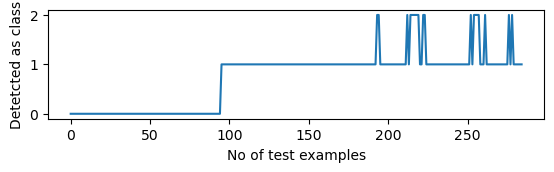

In [16]:
p=[]
for i in range(classes):
    for j in range(test_examples.shape[1]):
        sorted_indices=outputs[i,n_rounds-1,j,:].argsort()[-cap_size:][::-1]
        temp=[]
        for k in range(classes):
            op_sorted = activations[k,n_rounds-1,:].argsort()[-cap_size:][::-1]
            
            overlap = np.intersect1d(sorted_indices, op_sorted)
            overlap_percentage = len(overlap) / len(sorted_indices) * 100
            temp.append(overlap_percentage)
        
        max_index = temp.index(max(temp))
        p.append(max_index)
        #print(" class " +str(k)+ " with class " +str(j)+ " is", overlap_percentage)
    
plt.subplot(classes,1,k+1)
plt.plot(p)
plt.xlabel("No of test examples")
plt.ylabel("Detetcted as class")

In [17]:
p_array = np.array(p)

accuracy_check = p_array.reshape(classes, test_examples.shape[1])

for i in range(classes):

    exists_count =np.sum((accuracy_check[i,:]) == i)
    percentage_accuracy=(exists_count/vowel_samples_taken)*100
    print(" Class " +str(i)+ " got detected correctly with test examples with " + str(percentage_accuracy) +" %")

# Printing accuracy percentage of correct class being detected for each class

 Class 0 got detected correctly with test examples with 95.0 %
 Class 1 got detected correctly with test examples with 95.0 %
 Class 2 got detected correctly with test examples with 19.0 %
